In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
import yfinance as yf

In [2]:
# Download 15 years of monthly closing prices for AAPL and KO
data = yf.download(["AAPL", "KO"], period="15y", interval="1mo", auto_adjust=False)["Close"]

# Remove missing values
data = data.dropna()

data.head()

[*********************100%***********************]  2 of 2 completed


Ticker,AAPL,KO
Date,,
2011-05-01,12.422500,33.404999
2011-06-01,11.988214,33.645000
2011-07-01,13.945714,34.005001
2011-08-01,13.743929,35.224998
2011-09-01,13.618571,33.779999


In [3]:
# Data Source:
# We use monthly closing prices downloaded from the yfinance package, as required
# by the assignment instructions. These prices are used to construct the spread
# between the two assets.

Data Source Justification:

Although an Excel file with realized measures is provided, it is not used here.

The assignment requires using 15 years of monthly closing prices from yfinance.

Therefore, we retrieve the data directly from yfinance to construct the spread.

In [4]:
# We compute log prices and spread
data["log_AAPL"] = np.log(data["AAPL"])
data["log_KO"] = np.log(data["KO"])

# Spread : difference between log prices
data["spread"] = data["log_AAPL"] - data["log_KO"]

data[["AAPL", "KO", "log_AAPL", "log_KO", "spread"]].head()

Ticker,AAPL,KO,log_AAPL,log_KO,spread
Date,,,,,
2011-05-01,12.422500,33.404999,2.519509,3.508706,-0.989196
2011-06-01,11.988214,33.645000,2.483924,3.515864,-1.031941
2011-07-01,13.945714,34.005001,2.635172,3.526508,-0.891335
2011-08-01,13.743929,35.224998,2.620597,3.561756,-0.941159
2011-09-01,13.618571,33.779999,2.611434,3.519869,-0.908434


In [5]:
# The spread is defined as the difference between the logarithmic prices of the two assets.
# This transformation helps stabilize variance and is standard in pairs trading analysis.

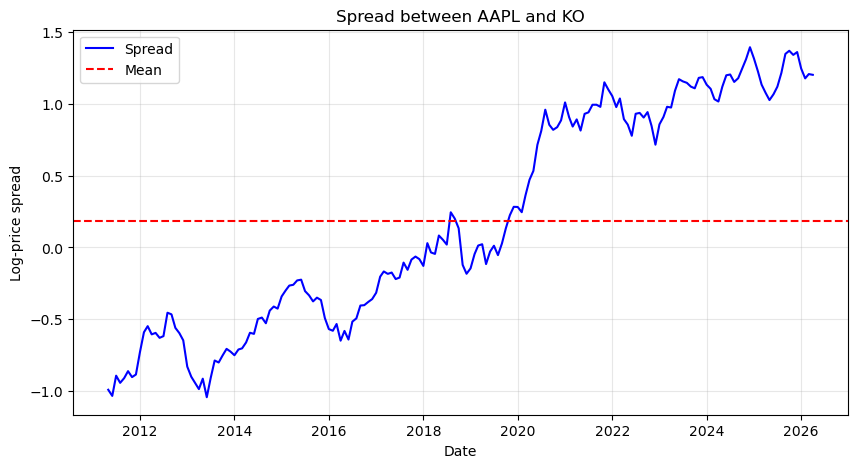

In [6]:
spread_mean = data["spread"].mean()

plt.figure(figsize=(10, 5))
plt.plot(data.index, data["spread"], color="blue", linewidth=1.5, label="Spread")
plt.axhline(spread_mean, color="red", linestyle="--", linewidth=1.5, label="Mean")
plt.title("Spread between AAPL and KO", fontsize=12)
plt.xlabel("Date")
plt.ylabel("Log-price spread")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [7]:
# The spread exhibits a clear upward trend rather than fluctuating around a stable mean.
# This suggests that the relationship between the two assets is not stable over time.
# Therefore, the spread does not appear to be mean-reverting.

Pour l'oral:
"We observe a clear upward trend in the spread, indicating that the two assets do not share a stable long-term relationship. This challenges the key assumption of mean reversion required for a pairs trading strategy."

<Figure size 800x400 with 0 Axes>

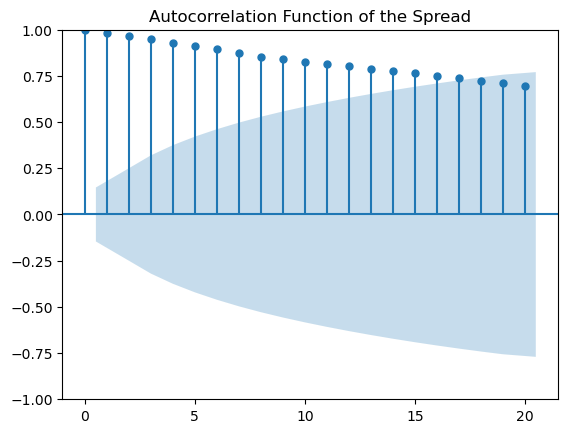

In [8]:
# ACF of Spread
plt.figure(figsize=(8, 4))
plot_acf(data["spread"], lags=20)
plt.title("Autocorrelation Function of the Spread")
plt.show()

In [9]:
# The ACF shows very high and persistent autocorrelation, with values close to 1
# and a slow decay across lags. This indicates that the spread is highly persistent
# and does not quickly revert to its mean.

# The lack of mean reversion suggests that the two assets may not be cointegrated,
# which is a key requirement for a successful pairs trading strategy.

Pour l'oral : 
"The ACF shows strong persistence, meaning the spread does not quickly revert to its mean, which weakens the validity of a pairs trading strategy."

In [10]:
# Returns
data["ret_AAPL"] = data["AAPL"].pct_change()
data["ret_KO"] = data["KO"].pct_change()

# Lead returns (t+1)
data["ret_AAPL_lead"] = data["ret_AAPL"].shift(-1)
data["ret_KO_lead"] = data["ret_KO"].shift(-1)

# Remove NaN created by pct_change and shift
data = data.dropna().copy()

# Recompute sample size and split AFTER dropna
n = len(data)
split = n // 2

print("n =", n)
print("split =", split)
print("rows in second half =", len(data.iloc[split:]))

n = 178
split = 89
rows in second half = 89


In [11]:
# Initialize trading variables
data["position_AAPL"] = 0
data["position_KO"] = 0
data["mu_t"] = np.nan
data["sigma_t"] = np.nan

In [12]:
# We implement an out-of-sample trading strategy.
# At each time t, we compute the historical mean and standard deviation
# of the spread using only past information. Trading decisions are based
# on deviations of the spread from its historical average.

current_position = 0  # 1 = hold AAPL, -1 = hold KO, 0 = cash

for t in range(split, n):
    hist_spread = data["spread"].iloc[:t]
    mu_t = hist_spread.mean()
    sigma_t = hist_spread.std()
    s_t = data["spread"].iloc[t]

    data.loc[data.index[t], "mu_t"] = mu_t
    data.loc[data.index[t], "sigma_t"] = sigma_t

    if current_position == 0:
        if s_t < mu_t - sigma_t:
            current_position = 1
        elif s_t > mu_t + sigma_t:
            current_position = -1

    elif current_position == 1:
        if s_t >= mu_t:
            current_position = 0

    elif current_position == -1:
        if s_t <= mu_t:
            current_position = 0

    data.loc[data.index[t], "position_AAPL"] = 1 if current_position == 1 else 0
    data.loc[data.index[t], "position_KO"] = 1 if current_position == -1 else 0

In [13]:
# Keep only the trading (out-of-sample) period
reg = data.iloc[split:].copy()

# AAPL regression
X1 = sm.add_constant(reg["position_AAPL"])
y1 = reg["ret_AAPL_lead"]

model1 = sm.OLS(y1, X1, missing='drop').fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:          ret_AAPL_lead   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Thu, 02 Apr 2026   Prob (F-statistic):                nan
Time:                        19:56:58   Log-Likelihood:                 99.893
No. Observations:                  89   AIC:                            -197.8
Df Residuals:                      88   BIC:                            -195.3
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0228      0.008      2.715

C:\Users\mathi\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


In [14]:
# The AAPL dummy is always equal to zero in the out-of-sample period.
# Therefore, the AAPL regression is not very informative, since the model cannot estimate
# the effect of a variable with no variation.

In [15]:
print(reg["position_AAPL"].value_counts())
print(reg["position_KO"].value_counts())

position_AAPL
0    89
Name: count, dtype: int64
position_KO
1    89
Name: count, dtype: int64


In [16]:
# The strategy generates no variation in trading positions during the out-of-sample period:
# it never buys AAPL and remains continuously invested in KO.
# As a result, the dummy variables contain no useful variation, which makes the
# regression analysis uninformative in this case.

In [17]:
print(reg[["spread", "mu_t", "sigma_t", "position_AAPL", "position_KO"]].tail(10))

Ticker        spread      mu_t   sigma_t  position_AAPL  position_KO
Date                                                                
2025-06-01  1.064686  0.125003  0.732988              0            1
2025-07-01  1.117580  0.130563  0.734369              0            1
2025-08-01  1.213379  0.136369  0.736096              0            1
2025-09-01  1.345320  0.142667  0.738535              0            1
2025-10-01  1.367135  0.149659  0.742060              0            1
2025-11-01  1.338572  0.156697  0.745667              0            1
2025-12-01  1.358078  0.163489  0.748888              0            1
2026-01-01  1.243728  0.170315  0.752173              0            1
2026-02-01  1.175292  0.176414  0.754373              0            1
2026-03-01  1.205116  0.182058  0.755964              0            1


In [18]:
# The trading rule generates no buy signals for AAPL in the out-of-sample period,
# as the spread never falls sufficiently below its historical mean.
# In contrast, the strategy takes positions in KO, since the spread remains
# persistently above the upper threshold.
# This asymmetry reflects the upward trend observed in the spread and
# confirms the lack of mean-reverting behavior.

In [19]:
# KO regression
X2 = sm.add_constant(reg["position_KO"])
y2 = reg["ret_KO_lead"]

model2 = sm.OLS(y2, X2, missing="drop").fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:            ret_KO_lead   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Thu, 02 Apr 2026   Prob (F-statistic):                nan
Time:                        19:56:58   Log-Likelihood:                 137.96
No. Observations:                  89   AIC:                            -273.9
Df Residuals:                      88   BIC:                            -271.4
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
position_KO     0.0061      0.005      1.108      

In [20]:
# The coefficient on the KO dummy cannot be meaningfully interpreted, as the position variable shows no variation over the trading period.
# Therefore, the regression does not provide valid evidence on the predictive power of the strategy.

Pour l'oral:
“Since the strategy generates no variation in positions, the regression cannot provide meaningful evidence on predictability.”

In [21]:
# Strategy returns
data["strategy_ret_gross"] = (
    data["position_AAPL"] * data["ret_AAPL_lead"] +
    data["position_KO"] * data["ret_KO_lead"]
)

# Keep only the out-of-sample trading period
trading_data = data.iloc[split:].copy()

# Capital without transaction costs
trading_data["capital_gross"] = 100 * (1 + trading_data["strategy_ret_gross"]).cumprod()

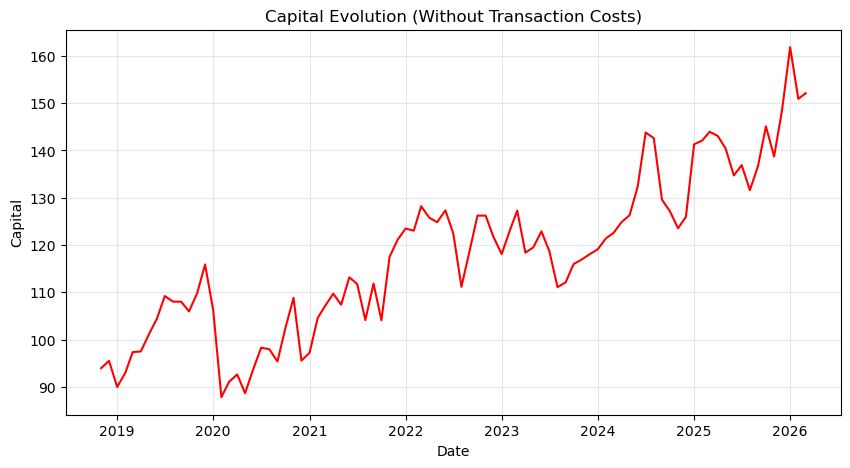

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(trading_data.index, trading_data["capital_gross"], linewidth=1.5, color="red")
plt.title("Capital Evolution (Without Transaction Costs)")
plt.xlabel("Date")
plt.ylabel("Capital")
plt.grid(alpha=0.3)
plt.show()

In [23]:
# The capital shows an upward trend over the trading period, suggesting potential profitability.
# However, this result should be interpreted with caution,
# as the strategy generates no variation in trading positions.
# Therefore, the observed performance may not be robust and could be driven by chance.

In [24]:
# Transaction costs
trading_data["state"] = trading_data["position_AAPL"] - trading_data["position_KO"]
trading_data["trade_change"] = trading_data["state"].diff().abs().fillna(abs(trading_data["state"]))

cost = 0.005

trading_data["strategy_ret_net"] = (
    trading_data["strategy_ret_gross"] - cost * trading_data["trade_change"]
)

trading_data["capital_net"] = 100 * (1 + trading_data["strategy_ret_net"]).cumprod()

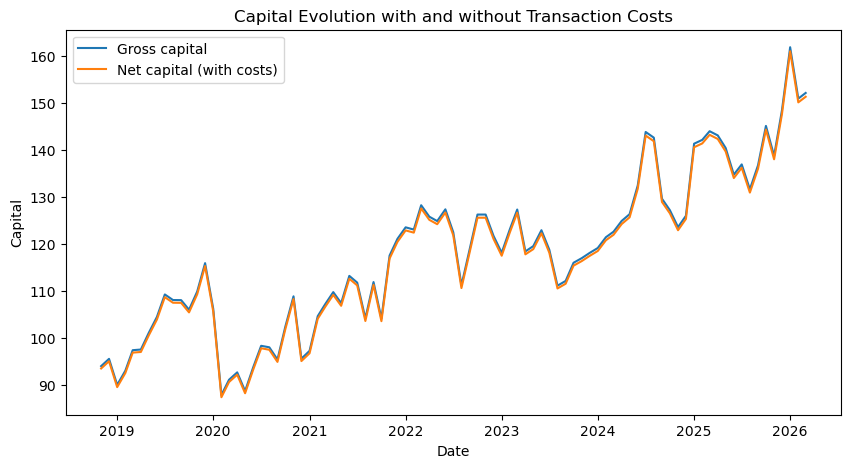

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(trading_data.index, trading_data["capital_gross"], label="Gross capital")
plt.plot(trading_data.index, trading_data["capital_net"], label="Net capital (with costs)")
plt.title("Capital Evolution with and without Transaction Costs")
plt.xlabel("Date")
plt.ylabel("Capital")
plt.legend()
plt.show()

In [26]:
# Transaction costs slightly reduce the strategy’s profitability, but do not eliminate it.
# However, the results should be interpreted with caution,
# as the strategy generates no meaningful variation in trading positions.
# This suggests that the observed performance may not be robust.

### Conclusion:
The analysis shows that the spread between AAPL and KO is not mean-reverting,
and the trading strategy generates no meaningful variation in positions.
As a result, the econometric analysis is not informative, and the observed
performance is unlikely to reflect a reliable trading opportunity.